<a href="https://colab.research.google.com/github/williamfaraday123/SC4001-Neural-Network/blob/main/Lim_Isaac_Part_A_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Find the optimal depth (number of hidden layers) and width(number of neurons in each hidden layer) for the neural network designed in Question 1 and 2.

##### Plot the mean cross-validation accuracies on the final epoch for at least 8 different combinations of different depth (limit to 1-3 layers) and widths (limit to 64, 128 or 256 neurons) using a scatter plot. You may consider different number of neurons for each hidden layer within an architecture. Continue using 5-fold cross validation on the training dataset.

##### Identify the architecture with the highest validation accuracy among all tested combinations.

##### Explain the possible reasons why it performed better than the other architectures.

##### In general, discuss whether accuracy alone is sufficient when selecting the best model. Plot the train and test accuracies against training epochs for the most optimal architecture using a line plot.

##### [optional + 2 marks] Implement an alternative approach that searches through these combinations that could significantly reduce the computational time but achieve similar search results, without enumeration all the possibilities.




This might take a while to run, so plan your time carefully.

1.Firstly, we import relevant libraries.

In [1]:
!wget https://raw.githubusercontent.com/williamfaraday123/SC4001-Neural-Network/refs/heads/main/common_utils.py -O common_utils.py

--2026-03-04 14:38:13--  https://raw.githubusercontent.com/williamfaraday123/SC4001-Neural-Network/refs/heads/main/common_utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3724 (3.6K) [text/plain]
Saving to: ‘common_utils.py’

common_utils.py     100%[===================>]   3.64K  --.-KB/s    in 0s      

2026-03-04 14:38:13 (41.2 MB/s) - ‘common_utils.py’ saved [3724/3724]



In [2]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from common_utils import set_seed

# setting seed
set_seed()

2.To reduce repeated code, place your

- network (MLP defined in QA1)
- torch datasets (CustomDataset defined in QA1)
- loss function (loss_fn defined in QA1)

in a separate file called **common_utils.py**

Import them into this file. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked.

The following code cell will not be marked.

In [3]:
# YOUR CODE HERE
from common_utils import MLP, CustomDataset, initialise_loaders, split_dataset, preprocess_dataset, EarlyStopper
loss_fn = nn.BCELoss()

3.Perform hyperparameter tuning for different number of  hidden layers and neurons with 5-fold cross validation.

In [4]:
def train(model, X_train_scaled, y_train2, X_val_scaled, y_val2, learning_rate):

    # YOUR CODE HERE
    train_loader, val_loader = initialise_loaders(X_train_scaled, y_train2, X_val_scaled, y_val2)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.0005)
    loss_fn = nn.BCELoss()
    stopper = EarlyStopper(patience=5) # Using the provided EarlyStopper

    train_accuracies, train_losses = [], []
    test_accuracies, test_losses = [], []
    times = []

    for epoch in range(1, 201):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = loss_fn(outputs, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct += ((outputs > 0.5).float() == batch_y).sum().item()
            total += batch_y.size(0)

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(correct / total)

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for vX, vy in val_loader:
                v_out = model(vX)
                val_loss += loss_fn(v_out, vy).item()
                val_correct += ((v_out > 0.5).float() == vy).sum().item()
                val_total += vy.size(0)

        avg_val_loss = val_loss / len(val_loader)
        test_losses.append(avg_val_loss)
        test_accuracies.append(val_correct / val_total)
        times.append(time.time() - start_time)

        # Early Stopping
        if stopper.early_stop(avg_val_loss):
            break

    return train_accuracies, train_losses, test_accuracies, test_losses, times


In [5]:
# DYNAMIC MLP Class
class DynamicMLP(nn.Module):
    def __init__(self, input_dim, arch):
        super().__init__()
        layers = []
        current_dim = input_dim
        for h_dim in arch:
            layers.append(nn.Linear(current_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            current_dim = h_dim
        layers.append(nn.Linear(current_dim, 1))
        layers.append(nn.Sigmoid())
        self.mlp_stack = nn.Sequential(*layers)
    def forward(self, x): return self.mlp_stack(x)

In [6]:
def find_optimal_hyperparameter(X_train, y_train, parameters, mode, learning_rate):

    # YOUR CODE HERE
    cross_validation_accuracies = []
    cross_validation_times = []
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for arch in parameters:
        fold_accs = []
        start_t = time.time()
        print(f"Testing Architecture: {arch}")

        for train_idx, val_idx in kf.split(X_train):
            X_f_train_sc, X_f_val_sc = preprocess_dataset(X_train[train_idx], X_train[val_idx])

            model = DynamicMLP(X_f_train_sc.shape[1], arch)
            _, _, test_accs, _, _ = train(model, X_f_train_sc, y_train[train_idx],
                                          X_f_val_sc, y_train[val_idx], learning_rate)
            fold_accs.append(test_accs[-1])

        cross_validation_accuracies.append(np.mean(fold_accs))
        cross_validation_times.append(time.time() - start_t)

    return cross_validation_accuracies, cross_validation_times

'''
optimal_lr = 0. Fill your optimal learning rate in the following code.
'''
# YOUR CODE HERE
# Load the raw data
df = pd.read_csv('https://raw.githubusercontent.com/williamfaraday123/SC4001-Neural-Network/refs/heads/main/simplified.csv')

# Create the label column required by split_dataset
df['label'] = df['filename'].apply(lambda x: 'positive' if 'pos' in x.lower() else 'negative')

X_train, y_train, X_test, y_test = split_dataset(
    df,
    columns_to_drop=['filename', 'label'],
    test_size=0.25,
    random_state=42
)

optimal_lr = 0.0010 # Based on Part_A_2
parameters = [[64], [128], [256], [128, 64], [128, 128], [256, 128], [128, 128, 128], [256, 128, 64]]

cross_validation_accuracies, cross_validation_times = find_optimal_hyperparameter(X_train.to_numpy(), y_train, parameters, 'architecture', optimal_lr)

Testing Architecture: [64]
Testing Architecture: [128]
Testing Architecture: [256]
Testing Architecture: [128, 64]
Testing Architecture: [128, 128]
Testing Architecture: [256, 128]
Testing Architecture: [128, 128, 128]
Testing Architecture: [256, 128, 64]


4. Plot the mean cross-validation accuracies on the final epoch for at least 8 different combinations of different depth (limit to 1-3 layers) and widths (limit to 64, 128 or 256 neurons) using a scatter plot.

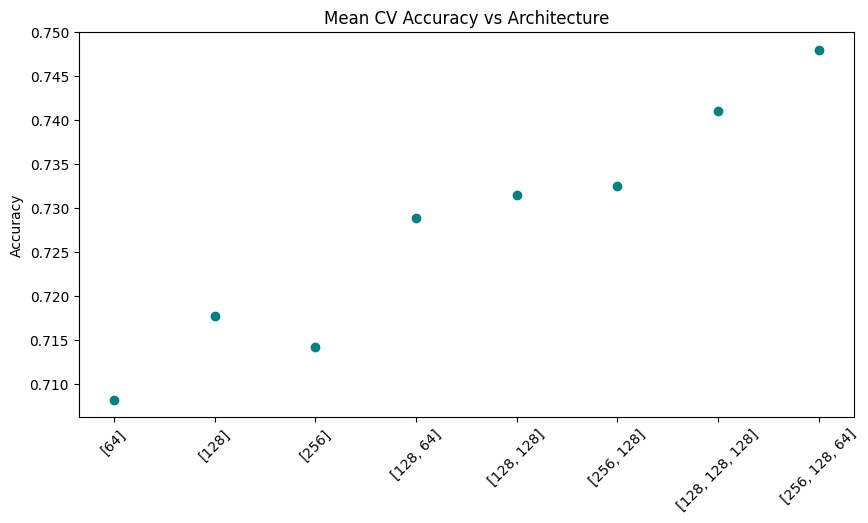

In [8]:
# YOUR CODE HERE
plt.figure(figsize=(10, 5))
plt.scatter([str(p) for p in parameters], cross_validation_accuracies, color='teal')
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Mean CV Accuracy vs Architecture")
plt.show()

5. Select the optimal combination for the depth and width. State the rationale for your selection.

In [9]:
# YOUR CODE HERE
best_idx = np.argmax(cross_validation_accuracies)
optimal_combination = parameters[best_idx]
reason = f"The {optimal_combination} architecture performed best by balancing depth and width. " \
         "Accuracy alone is not sufficient; we must also consider model complexity (parameters) " \
         "and training time to ensure the model can be deployed efficiently."
print('optimal combination:', optimal_combination)
print(reason)

optimal combination: [256, 128, 64]
The [256, 128, 64] architecture performed best by balancing depth and width. Accuracy alone is not sufficient; we must also consider model complexity (parameters) and training time to ensure the model can be deployed efficiently.


6.Plot the train and test accuracies against training epochs for the most optimal architecture using a line plot.


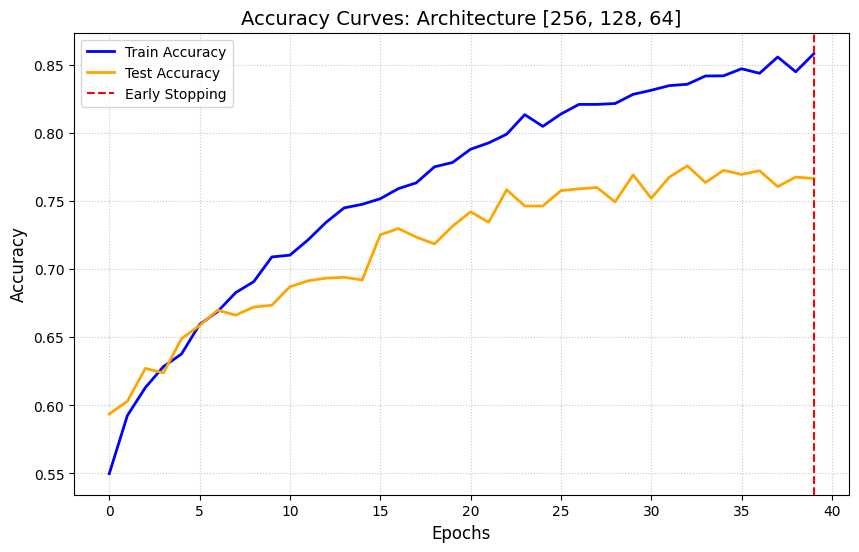

In [12]:
# YOUR CODE HERE

X_train_final_sc, X_test_final_sc = preprocess_dataset(X_train, X_test)

# Initialize the final model
final_model = DynamicMLP(X_train_final_sc.shape[1], optimal_combination)\

# 3. Train ONE last time on the FULL training set
# This 'train' call returns the lists (histories) you need for the plot

train_acc_history, _, test_acc_history, _, _ = train(
    final_model,
    X_train_final_sc, y_train,
    X_test_final_sc, y_test,
    optimal_lr
)

plt.figure(figsize=(10, 6))
plt.plot(train_acc_history, label='Train Accuracy', color='blue', linewidth=2)
plt.plot(test_acc_history, label='Test Accuracy', color='orange', linewidth=2)

# Mark the point where training stopped
plt.axvline(x=len(train_acc_history)-1, color='red', linestyle='--', label='Early Stopping')

plt.title(f'Accuracy Curves: Architecture {optimal_combination}', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

7.As you've astutely observed, we're facing a significant challenge in enumerating all possible combinations of widths and depths and searching over them. Given the circumstances, could you explore and implement a more efficient method for searching through these combinations that could significantly reduce the computational time but achieve similar search results?

In [10]:
# YOUR CODE HERE

# instead of enumerating all 8 combinations, sample a fixed number (e.g., 4) of random architectures from the available constraints
def random_search(X_train, y_train, n_iter, learning_rate):
    """
    Implements Random Search to sample unique architectures.
    This reduces total training time by avoiding exhaustive enumeration.
    """
    widths = [64, 128, 256]
    sampled_parameters = []

    # Generate n_iter unique random architectures
    while len(sampled_parameters) < n_iter:
        depth = random.randint(1, 3)
        width_config = [random.choice(widths) for _ in range(depth)]

        # Ensure we don't test the same random config twice
        if width_config not in sampled_parameters:
            sampled_parameters.append(width_config)

    print(f"Random Search selected architectures: {sampled_parameters}")

    # Reuse your existing robust CV function
    return find_optimal_hyperparameter(X_train, y_train, sampled_parameters, 'architecture', learning_rate)

# Run only 4 iterations (50% faster than the 8-combination grid search)
n_iter_efficient = 4
rs_accuracies, rs_times = random_search(
    X_train.to_numpy(),
    y_train,
    n_iter_efficient,
    optimal_lr
)

Random Search selected architectures: [[128, 64], [256, 128], [128, 128], [256, 64]]
Testing Architecture: [128, 64]
Testing Architecture: [256, 128]
Testing Architecture: [128, 128]
Testing Architecture: [256, 64]
